In [1]:
import numpy as np
import matplotlib.pyplot as pl
from scipy.interpolate import CubicSpline
import scipy as sp
from scipy import integrate

c = 3e8
G = 6.67e-11
pi = np.pi
const = 96/5*pi**(8/3)*(G/c**3)**(5/3)

In [4]:
4/3*pi*(20)**3

33510.32163829113

## Interpolating ephemeris

In [2]:
ephemeris = np.loadtxt("earth00-40-DE440.dat", delimiter = '\t', skiprows=18)

In [3]:
[t_eph, pos_x, pos_y, pos_z, vel_x, vel_y, vel_z, 
 acc_x, acc_y, acc_z] = ephemeris.T
v_arr = np.array([vel_x, vel_y, vel_z])
acc_arr = np.array([acc_x, acc_y, acc_z])

interp_v = CubicSpline(t_eph, v_arr.T)
interp_acc = CubicSpline(t_eph, acc_arr.T)

## Choosing params

In [4]:
def f_calc(f0, beta, t):
    return f0*(1-8/3*beta*t)**(-3/8)

def phi_calc(f0, beta, t):
    return -6*pi/5*f0*(1-8./3.*beta*t)**(5/8)/beta

In [5]:
H_lat = 119.41 * np.pi/180 # rad
H_lng = 46.45 * np.pi/180 # rad

params = dict(ra = 0.5, dec = 0.5, eta = 0.5, psi = 0.5, lat = H_lat, 
              lng = H_lng, az = 0.5)

n_hat = (np.cos(params['ra'])*np.cos(params['dec']),
        np.sin(params['ra'])*np.cos(params['dec']),
        np.sin(params['dec']))

f0 = 20.5
Mc = 1e-4 * 2e30
beta = const*f0**(8/3)*Mc**(5/3)

## Numerical integration

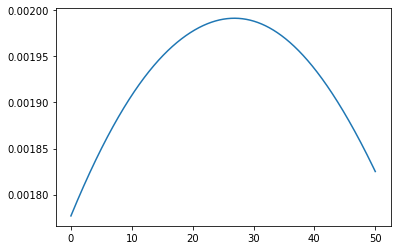

In [16]:
day = 86400
t_space = np.linspace(0, 50*day, int(1e5)) #need to add t_eph[0] when using the interpolated functions
tDay_space = t_space / day

nondoppler_f = f_calc(f0, beta, t_space)
doppler_f = f_calc(f0, beta, t_space) * (1+np.dot(interp_v(t_space+t_eph[0]), n_hat))
pl.plot(tDay_space, nondoppler_f - doppler_f) #shows the doppler modulation

In [18]:
nondoppler_f[0]

20.5

In [72]:
numerical_phi0 = 2*np.pi*np.array([integrate.trapezoid(doppler_f[0:i], t_space[0:i]) for i in range(len(t_space))])
numerical_phi1 = 2*np.pi*np.array([integrate.quad(lambda t: f_calc(f0, beta, t) * (1+np.dot(interp_v(t+t_eph[0]), n_hat)),
                                t_space[0], t_space[i])[0] for i in range(len(t_space))])

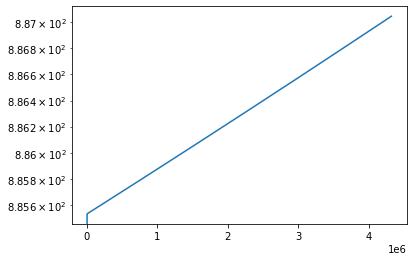

In [42]:
pl.semilogy(t_space, numerical_phi1 - numerical_phi0) #difference but mostly constant after initial jump at early t

In [60]:
temp_phi = phi_calc(f0, beta, t_space) - phi_calc(f0, beta, 0)
approx_phi = temp_phi * (1+np.dot(interp_v(t_space+t_eph[0]), n_hat))

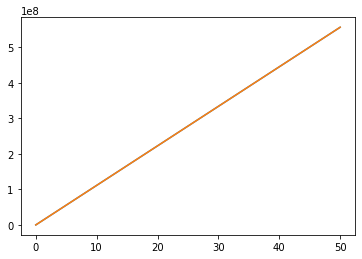

In [73]:
pl.plot(tDay_space, approx_phi)
pl.plot(tDay_space, numerical_phi1)

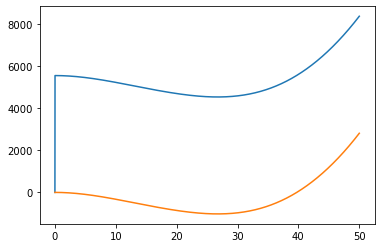

In [77]:
pl.plot(tDay_space, approx_phi - numerical_phi0)
pl.plot(tDay_space, approx_phi - numerical_phi1)

In [78]:
# How much is the frequency difference?
# Does accouonting for acceleration reduce this further?

In [6]:
# Using t=30 days for long enough to see Doppler effects
t_space = np.linspace(t_eph[0], t_eph[0]+50*day, int(1e5))
f_source = f_calc(f0, beta, t_space - t_space[0])
f_doppler = f_source*(1+np.dot(interp_v(t_space), n_hat))
# pl.plot(t_space, ((f_source - f_doppler)/f_source)) #Check you can see the effects

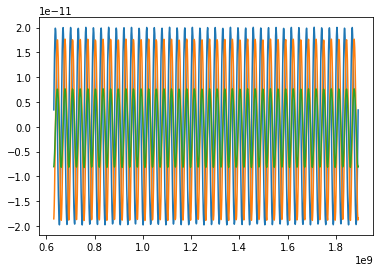

In [37]:
pl.plot(t_eph, acc_x)
pl.plot(t_eph, acc_y)
pl.plot(t_eph, acc_z)